In [1]:
import numpy as np
import pandas as pd
import json
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ── Load artifacts ──────────────────────────────────────────────────────────
pipeline_xgb = joblib.load("xgb_smote_pipeline.pkl")
X_train = np.load("X_train.npy")
X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")
feature_names = json.load(open("feature_names.json"))
baseline_metrics = json.load(open("baseline_metrics.json"))

X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df = pd.DataFrame(X_test, columns=feature_names)

In [5]:
# ── Load & preprocess drift CSVs ────────────────────────────────────────────
def preprocess(df):
    df = df.drop_duplicates()
    df["Amount"] = np.log(df["Amount"] + 0.001)
    return df

drift_files = {
    "drift_1": r"..\..\data\drift_1.csv",
    "drift_2": r"..\..\data\drift_2.csv",
    "drift_3": r"..\..\data\drift_3.csv",
    "drift_4": r"..\..\data\drift_4.csv",
    "drift_5": r"..\..\data\drift_5.csv",
}
drift_dfs = {}
for name, path in drift_files.items():
    df = pd.read_csv(path)
    df = preprocess(df)
    drift_dfs[name] = df
    print(f"{name}: {df.shape}, fraud rate: {df['Class'].mean():.4f}")

drift_1: (15000, 32), fraud rate: 0.0019
drift_2: (15000, 32), fraud rate: 0.0016
drift_3: (18000, 32), fraud rate: 0.0052
drift_4: (15000, 32), fraud rate: 0.0017
drift_5: (15000, 32), fraud rate: 0.0200


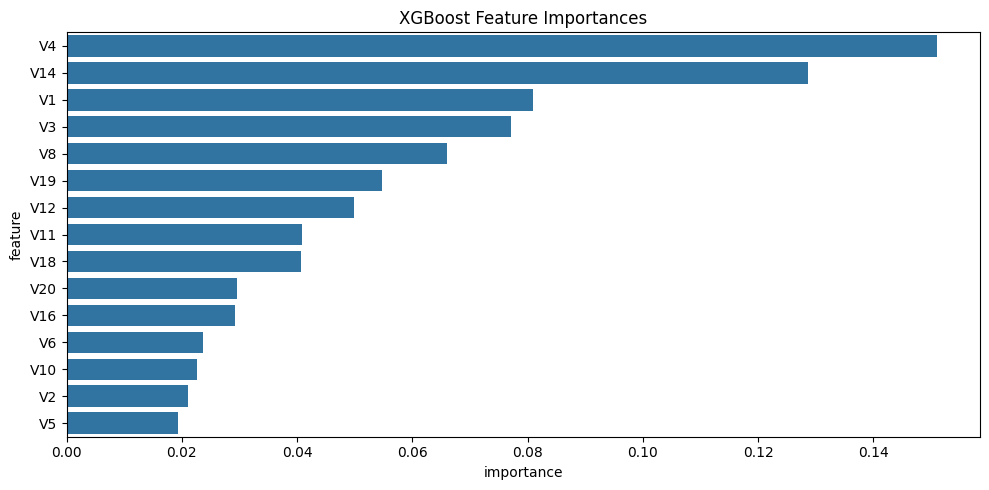

In [6]:
# ── Top features by XGBoost importance ─────────────────────────────────────
xgb_model = pipeline_xgb.named_steps["xgb"]
importances = xgb_model.feature_importances_
top_features = [feature_names[i] for i in np.argsort(importances)[::-1][:10]]

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df.head(15), x="importance", y="feature")
plt.title("XGBoost Feature Importances")
plt.tight_layout()
plt.savefig("feature_importances.png", dpi=150)
plt.show()

In [7]:
# ── TASK 2: Distribution analysis ───────────────────────────────────────────
# Summary stats: train vs each drift dataset

stat_frames = []
for name, df in drift_dfs.items():
    stats_df = df[top_features].describe().T[["mean", "std", "min", "max"]]
    stats_df["dataset"] = name
    stat_frames.append(stats_df)

train_stats = X_train_df[top_features].describe().T[["mean", "std", "min", "max"]]
train_stats["dataset"] = "train"
stat_frames.insert(0, train_stats)

summary = pd.concat(stat_frames)
print(summary)

         mean       std        min        max  dataset
V4  -0.002222  1.415649  -5.683171  16.875344    train
V14  0.001822  0.953671 -19.214325  10.526766    train
V1   0.004318  1.948313 -56.407510   2.454930    train
V3   0.001375  1.512782 -48.325589   9.382558    train
V8   0.000444  1.179931 -73.216718  19.587773    train
V19 -0.000279  0.813425  -7.213527   5.591971    train
V12 -0.001383  0.997287 -18.683715   7.848392    train
V11 -0.000001  1.019544  -4.797473  12.018913    train
V18  0.001566  0.836811  -9.498746   5.041069    train
V20  0.000378  0.768462 -54.497720  39.420904    train
V4  -0.007502  1.421920  -6.322708   5.105043  drift_1
V14 -0.006925  0.958226  -3.589727   3.753684  drift_1
V1   1.990859  2.296793  -6.035251  10.246275  drift_1
V3  -0.002140  1.515078  -5.591985   5.442771  drift_1
V8   0.001958  1.203480  -5.260186   5.448775  drift_1
V19 -0.005131  0.805978  -3.192993   2.896844  drift_1
V12 -0.007644  0.985324  -4.022764   3.902334  drift_1
V11  0.004

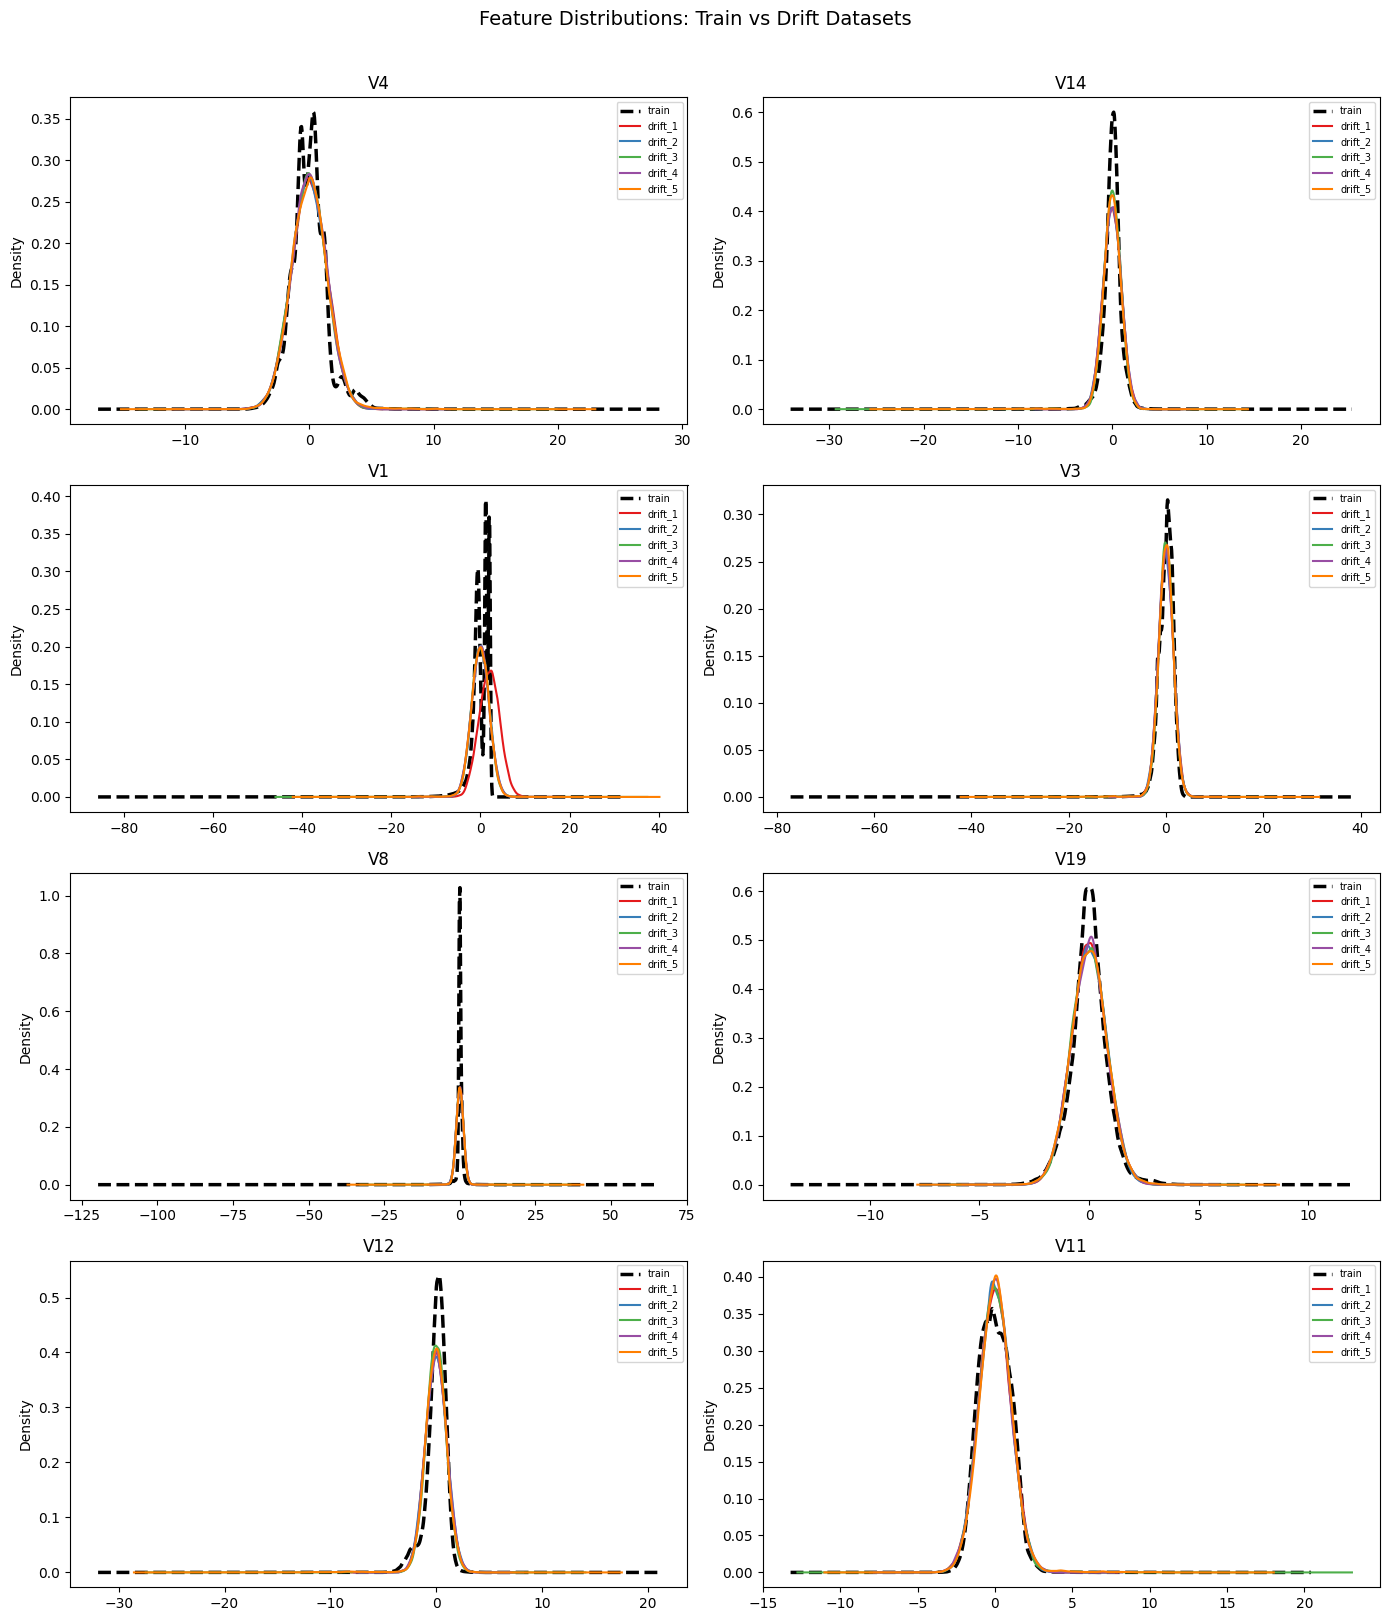

In [8]:
# ── KDE plots: train vs each drift for top 8 features ──────────────────────
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

colors = ["black", "#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00"]
labels = ["train"] + list(drift_dfs.keys())
datasets = [X_train_df] + [df[top_features] for df in drift_dfs.values()]

for i, feat in enumerate(top_features[:8]):
    ax = axes[i]
    for df, label, color in zip(datasets, labels, colors):
        df[feat].plot.kde(ax=ax, label=label, color=color,
                          linewidth=1.5 if label != "train" else 2.5,
                          linestyle="--" if label == "train" else "-")
    ax.set_title(feat)
    ax.legend(fontsize=7)
    ax.set_xlabel("")

plt.suptitle("Feature Distributions: Train vs Drift Datasets", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("kde_plots.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# ── TASK 3: Drift detection — KS test ───────────────────────────────────────
ks_stats = {}
ks_pvals = {}

for name, df in drift_dfs.items():
    stats_row, pval_row = {}, {}
    for feat in feature_names:
        stat, pval = stats.ks_2samp(X_train_df[feat], df[feat])
        stats_row[feat] = round(stat, 4)
        pval_row[feat] = round(pval, 4)
    ks_stats[name] = stats_row
    ks_pvals[name] = pval_row

ks_stats_df = pd.DataFrame(ks_stats).T  # shape: (5 datasets x 30 features)
ks_pvals_df = pd.DataFrame(ks_pvals).T

print("KS Statistics (top 10 features):")
print(ks_stats_df[top_features])

KS Statistics (top 10 features):
             V4     V14      V1      V3      V8     V19     V12     V11  \
drift_1  0.0530  0.0831  0.4555  0.0545  0.2508  0.0369  0.0950  0.0242   
drift_2  0.0507  0.0828  0.1212  0.0591  0.2472  0.0395  0.0932  0.0319   
drift_3  0.0470  0.0657  0.1104  0.0492  0.2565  0.0436  0.0887  0.0264   
drift_4  0.0526  0.0815  0.1166  0.0576  0.2456  0.0386  0.0910  0.0282   
drift_5  0.0566  0.0731  0.1135  0.0508  0.2452  0.0395  0.0957  0.0449   

            V18     V20  
drift_1  0.0300  0.2095  
drift_2  0.0259  0.2069  
drift_3  0.0284  0.2115  
drift_4  0.0260  0.2099  
drift_5  0.0266  0.2073  


In [10]:
# ── PSI function ─────────────────────────────────────────────────────────────
def compute_psi(reference, production, bins=10):
    breakpoints = np.linspace(
        min(reference.min(), production.min()),
        max(reference.max(), production.max()),
        bins + 1
    )
    ref_counts = np.histogram(reference, bins=breakpoints)[0]
    prod_counts = np.histogram(production, bins=breakpoints)[0]

    # Avoid division by zero
    ref_pct = np.where(ref_counts == 0, 0.0001, ref_counts / len(reference))
    prod_pct = np.where(prod_counts == 0, 0.0001, prod_counts / len(production))

    psi_values = (prod_pct - ref_pct) * np.log(prod_pct / ref_pct)
    return round(np.sum(psi_values), 4)

psi_scores = {}
for name, df in drift_dfs.items():
    row = {}
    for feat in feature_names:
        row[feat] = compute_psi(X_train_df[feat].values, df[feat].values)
    psi_scores[name] = row

psi_df = pd.DataFrame(psi_scores).T
print("PSI Scores (top 10 features):")
print(psi_df[top_features])

PSI Scores (top 10 features):
             V4     V14      V1      V3      V8     V19     V12     V11  \
drift_1  0.0467  0.0199  2.0469  0.0277  0.2207  0.0290  0.0722  0.0070   
drift_2  0.0577  0.0217  0.0559  0.0295  0.2157  0.0326  0.0725  0.0052   
drift_3  0.0416  0.0036  0.0181  0.0220  0.2023  0.0274  0.0618  0.0079   
drift_4  0.0469  0.0232  0.0126  0.0294  0.2207  0.0289  0.0606  0.0048   
drift_5  0.0442  0.0117  0.0604  0.0063  0.0231  0.0238  0.0684  0.0130   

            V18     V20  
drift_1  0.0174  0.0067  
drift_2  0.0140  0.0073  
drift_3  0.0159  0.0049  
drift_4  0.0147  0.0085  
drift_5  0.0181  0.0065  


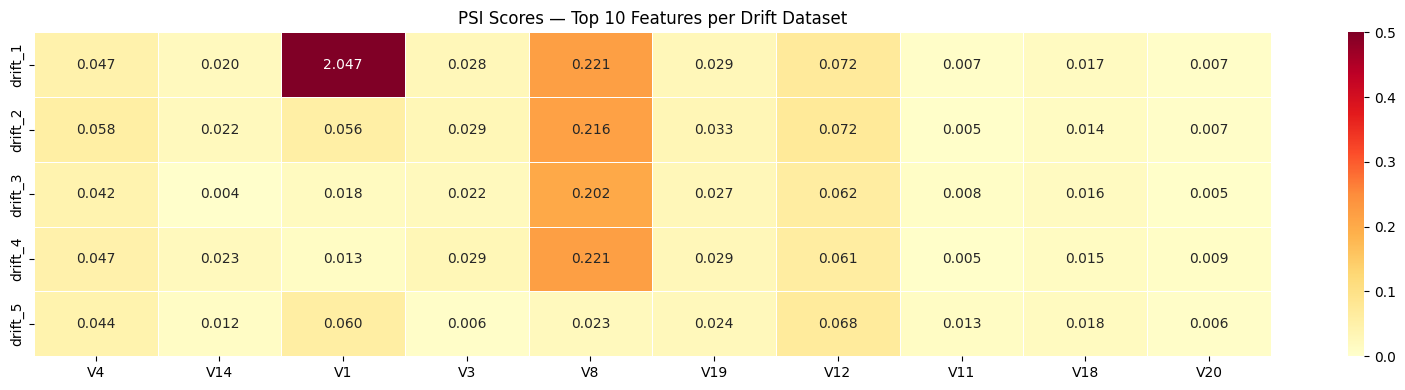


PSI Interpretation:
< 0.10  → No significant drift
0.10 – 0.25 → Moderate drift (monitor)
> 0.25  → Significant drift (alert / retrain)


In [11]:
# ── PSI heatmap ──────────────────────────────────────────────────────────────
plt.figure(figsize=(16, 4))
sns.heatmap(
    psi_df[top_features],
    annot=True, fmt=".3f", cmap="YlOrRd",
    linewidths=0.5,
    vmin=0, vmax=0.5
)
plt.title("PSI Scores — Top 10 Features per Drift Dataset")
plt.tight_layout()
plt.savefig("psi_heatmap.png", dpi=150)
plt.show()

# PSI legend
print("\nPSI Interpretation:")
print("< 0.10  → No significant drift")
print("0.10 – 0.25 → Moderate drift (monitor)")
print("> 0.25  → Significant drift (alert / retrain)")

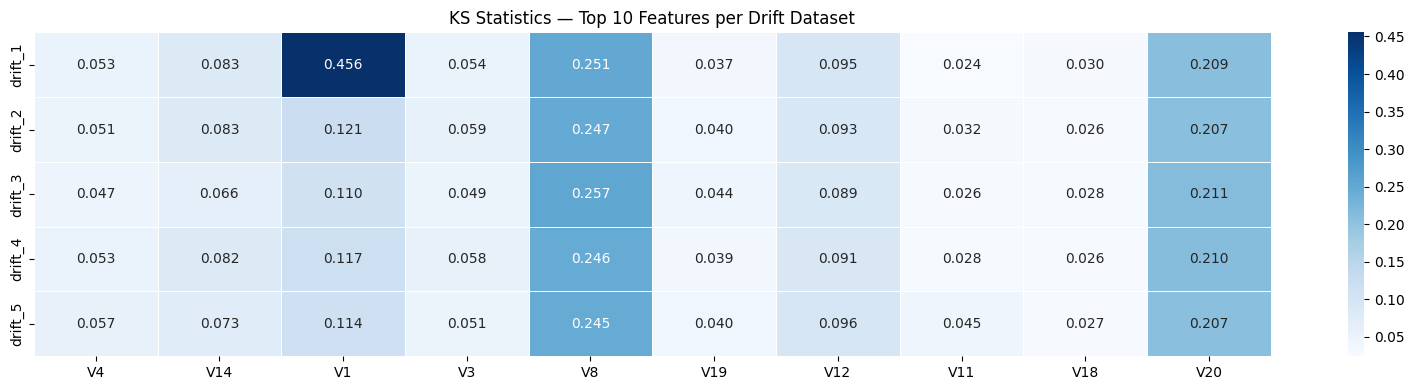

In [12]:
# ── KS heatmap (top features only) ──────────────────────────────────────────
plt.figure(figsize=(16, 4))
sns.heatmap(
    ks_stats_df[top_features],
    annot=True, fmt=".3f", cmap="Blues",
    linewidths=0.5
)
plt.title("KS Statistics — Top 10 Features per Drift Dataset")
plt.tight_layout()
plt.savefig("ks_heatmap.png", dpi=150)
plt.show()

In [13]:
# ── Flagged features summary ─────────────────────────────────────────────────
print("=== DRIFT SUMMARY ===\n")
for name in drift_dfs:
    flagged_ks = [f for f in feature_names if ks_pvals_df.loc[name, f] < 0.05]
    flagged_psi = [f for f in feature_names if psi_df.loc[name, f] > 0.25]
    print(f"{name}:")
    print(f"  KS flagged ({len(flagged_ks)} features): {flagged_ks[:8]}")
    print(f"  PSI critical ({len(flagged_psi)} features): {flagged_psi[:8]}")
    print()

=== DRIFT SUMMARY ===

drift_1:
  KS flagged (30 features): ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7']
  PSI critical (3 features): ['Time', 'V1', 'V21']

drift_2:
  KS flagged (29 features): ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7']
  PSI critical (3 features): ['Time', 'V21', 'Amount']

drift_3:
  KS flagged (30 features): ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7']
  PSI critical (2 features): ['Time', 'V21']

drift_4:
  KS flagged (30 features): ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7']
  PSI critical (2 features): ['Time', 'V21']

drift_5:
  KS flagged (29 features): ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7']
  PSI critical (2 features): ['Time', 'V21']



In [14]:
# ── TASK 4: Performance degradation ─────────────────────────────────────────
from sklearn.metrics import (f1_score, roc_auc_score,
                             precision_score, recall_score)

results = []

# Baseline on test set
results.append({
    "dataset": "baseline (test)",
    "f1": baseline_metrics["f1"],
    "roc_auc": baseline_metrics["roc_auc"],
    "precision": baseline_metrics["precision"],
    "recall": baseline_metrics["recall"],
    "fraud_rate": y_test.mean()
})

# Evaluate on each drift dataset
for name, df in drift_dfs.items():
    X_d = df[feature_names].values
    y_d = df["Class"].values.astype(int)

    y_pred_d = pipeline_xgb.predict(X_d)
    y_prob_d = pipeline_xgb.predict_proba(X_d)[:, 1]

    results.append({
        "dataset": name,
        "f1": round(f1_score(y_d, y_pred_d), 4),
        "roc_auc": round(roc_auc_score(y_d, y_prob_d), 4),
        "precision": round(precision_score(y_d, y_pred_d), 4),
        "recall": round(recall_score(y_d, y_pred_d), 4),
        "fraud_rate": round(y_d.mean(), 4)
    })

perf_df = pd.DataFrame(results).set_index("dataset")
print(perf_df)

                       f1   roc_auc  precision  recall  fraud_rate
dataset                                                           
baseline (test)  0.761905  0.962837   0.727273  0.8000    0.001586
drift_1          0.000000  0.555100   0.000000  0.0000    0.001900
drift_2          0.000000  0.498000   0.000000  0.0000    0.001600
drift_3          0.226800  0.921200   0.140700  0.5851    0.005200
drift_4          0.000000  0.372900   0.000000  0.0000    0.001700
drift_5          0.418400  0.921200   0.351500  0.5167    0.020000


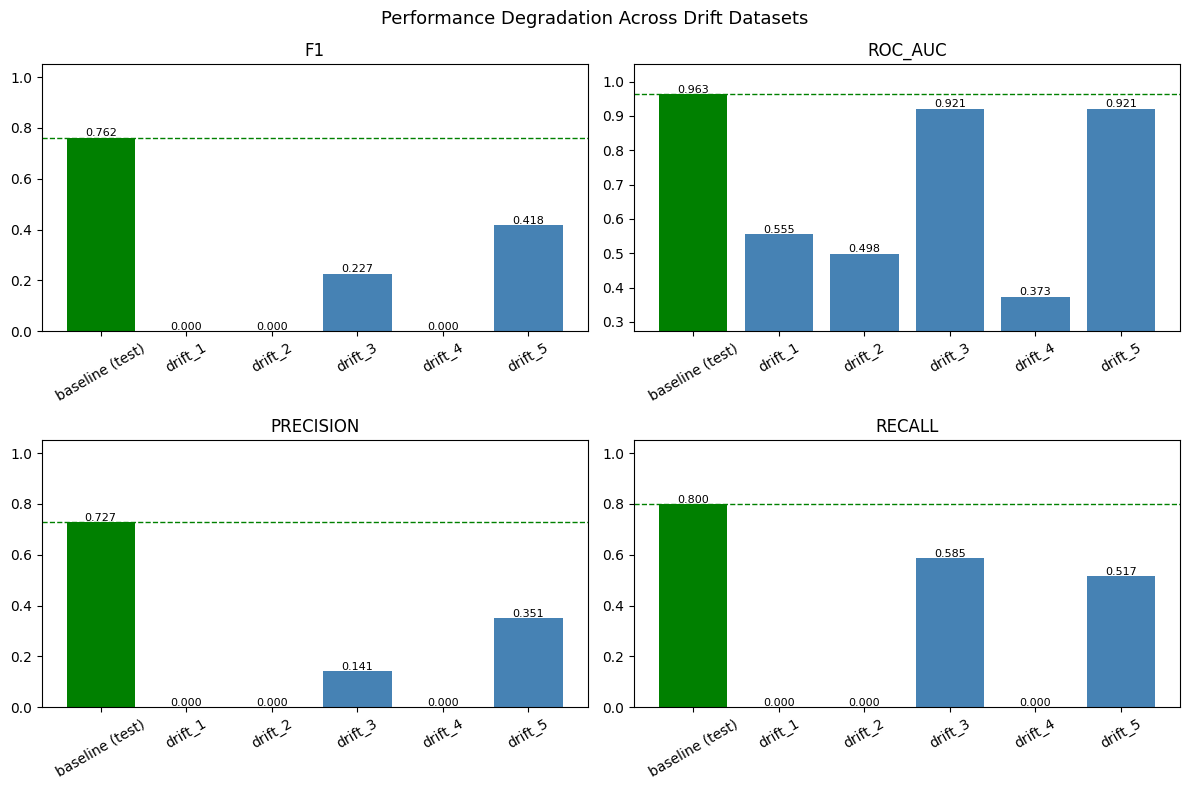

In [15]:
# ── Degradation plot ─────────────────────────────────────────────────────────
metrics_to_plot = ["f1", "roc_auc", "precision", "recall"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    vals = perf_df[metric].values
    labels = perf_df.index.tolist()
    colors = ["green"] + ["steelblue"] * (len(vals) - 1)
    bars = ax.bar(labels, vals, color=colors)
    ax.axhline(vals[0], color="green", linestyle="--", linewidth=1, label="baseline")
    ax.set_title(metric.upper())
    ax.set_ylim(max(0, min(vals) - 0.1), 1.05)
    ax.tick_params(axis="x", rotation=30)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", fontsize=8)

plt.suptitle("Performance Degradation Across Drift Datasets", fontsize=13)
plt.tight_layout()
plt.savefig("degradation.png", dpi=150)
plt.show()

In [16]:
# ── Trace degradation back to drift ─────────────────────────────────────────
# Correlate PSI of top features with F1 drop per dataset

f1_drops = perf_df["f1"] - perf_df.loc["baseline (test)", "f1"]
f1_drops = f1_drops.drop("baseline (test)")

top_psi = psi_df[top_features].mean(axis=1)  # avg PSI across top features

print("F1 drop vs avg PSI (top features):\n")
for name in f1_drops.index:
    print(f"  {name}: F1 drop={f1_drops[name]:+.4f}, avg PSI={top_psi[name]:.4f}")

F1 drop vs avg PSI (top features):

  drift_1: F1 drop=-0.7619, avg PSI=0.2494
  drift_2: F1 drop=-0.7619, avg PSI=0.0512
  drift_3: F1 drop=-0.5351, avg PSI=0.0406
  drift_4: F1 drop=-0.7619, avg PSI=0.0450
  drift_5: F1 drop=-0.3435, avg PSI=0.0276


In [17]:
# ── TASK 5: Automated drift check function ───────────────────────────────────
THRESHOLDS = {
    "psi_warning": 0.10,
    "psi_critical": 0.25,
    "ks_pvalue": 0.05,
    "f1_degradation": 0.05,
    "auc_degradation": 0.03,
}

def check_drift(new_df, reference_df, feature_names, thresholds=THRESHOLDS):
    report = {"features": {}, "alerts": [], "recommendation": "OK"}

    for feat in feature_names:
        ks_stat, ks_pval = stats.ks_2samp(reference_df[feat], new_df[feat])
        psi = compute_psi(reference_df[feat].values, new_df[feat].values)

        feature_report = {
            "ks_stat": round(ks_stat, 4),
            "ks_pval": round(ks_pval, 4),
            "psi": round(psi, 4),
            "ks_flagged": ks_pval < thresholds["ks_pvalue"],
            "psi_level": (
                "critical" if psi > thresholds["psi_critical"]
                else "warning" if psi > thresholds["psi_warning"]
                else "ok"
            )
        }
        report["features"][feat] = feature_report

        if feature_report["psi_level"] == "critical":
            report["alerts"].append(f"CRITICAL PSI: {feat} (PSI={psi:.3f})")
        elif feature_report["psi_level"] == "warning":
            report["alerts"].append(f"WARNING PSI: {feat} (PSI={psi:.3f})")
        if feature_report["ks_flagged"]:
            report["alerts"].append(f"KS drift: {feat} (p={ks_pval:.4f})")

    critical_count = sum(
        1 for f in report["features"].values() if f["psi_level"] == "critical"
    )
    if critical_count >= 3:
        report["recommendation"] = "RETRAIN"
    elif critical_count >= 1:
        report["recommendation"] = "ALERT"

    return report

# Run on all drift datasets
for name, df in drift_dfs.items():
    report = check_drift(df[feature_names], X_train_df, feature_names)
    print(f"\n{name} → Recommendation: {report['recommendation']}")
    print(f"  Alerts ({len(report['alerts'])}):")
    for alert in report['alerts'][:5]:
        print(f"    {alert}")


drift_1 → Recommendation: RETRAIN
  Alerts (35):
    CRITICAL PSI: Time (PSI=8.283)
    KS drift: Time (p=0.0000)
    CRITICAL PSI: V1 (PSI=2.047)
    KS drift: V1 (p=0.0000)
    KS drift: V2 (p=0.0000)

drift_2 → Recommendation: RETRAIN
  Alerts (33):
    CRITICAL PSI: Time (PSI=8.283)
    KS drift: Time (p=0.0000)
    KS drift: V1 (p=0.0000)
    KS drift: V2 (p=0.0000)
    KS drift: V3 (p=0.0000)

drift_3 → Recommendation: ALERT
  Alerts (34):
    CRITICAL PSI: Time (PSI=8.283)
    KS drift: Time (p=0.0000)
    KS drift: V1 (p=0.0000)
    KS drift: V2 (p=0.0000)
    KS drift: V3 (p=0.0000)

drift_4 → Recommendation: ALERT
  Alerts (34):
    CRITICAL PSI: Time (PSI=8.283)
    KS drift: Time (p=0.0000)
    KS drift: V1 (p=0.0000)
    KS drift: V2 (p=0.0000)
    KS drift: V3 (p=0.0000)

drift_5 → Recommendation: ALERT
  Alerts (32):
    CRITICAL PSI: Time (PSI=8.284)
    KS drift: Time (p=0.0000)
    KS drift: V1 (p=0.0000)
    KS drift: V2 (p=0.0000)
    KS drift: V3 (p=0.0000)


In [19]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

for name, df in drift_dfs.items():
    X_d = df[feature_names].values
    y_d = df["Class"].values.astype(int)
    y_pred_d = pipeline_xgb.predict(X_d)
    y_prob_d = pipeline_xgb.predict_proba(X_d)[:, 1]

    if y_d.sum() == 0:
        print(f"{name}: no fraud labels — skipping F1/precision/recall, AUC only")
        print(f"  ROC-AUC: {roc_auc_score(y_d, y_prob_d):.4f}")
        continue

    print(f"{name}: F1={f1_score(y_d, y_pred_d):.4f}, "
          f"P={precision_score(y_d, y_pred_d):.4f}, "
          f"R={recall_score(y_d, y_pred_d):.4f}, "
          f"AUC={roc_auc_score(y_d, y_prob_d):.4f}")

drift_1: F1=0.0000, P=0.0000, R=0.0000, AUC=0.5551
drift_2: F1=0.0000, P=0.0000, R=0.0000, AUC=0.4980
drift_3: F1=0.2268, P=0.1407, R=0.5851, AUC=0.9212
drift_4: F1=0.0000, P=0.0000, R=0.0000, AUC=0.3729
drift_5: F1=0.4184, P=0.3515, R=0.5167, AUC=0.9212


In [20]:
for name, df in drift_dfs.items():
    y_d = df["Class"].values.astype(int)
    y_pred_d = pipeline_xgb.predict(df[feature_names].values)
    
    actual = y_d.sum()
    predicted = y_pred_d.sum()
    overlap = ((y_d == 1) & (y_pred_d == 1)).sum()
    print(f"{name}: actual_fraud={actual}, predicted_fraud={predicted}, correct={overlap}")

drift_1: actual_fraud=29, predicted_fraud=145, correct=0
drift_2: actual_fraud=24, predicted_fraud=164, correct=0
drift_3: actual_fraud=94, predicted_fraud=391, correct=55
drift_4: actual_fraud=25, predicted_fraud=271, correct=0
drift_5: actual_fraud=300, predicted_fraud=441, correct=155


In [21]:
for name in drift_dfs:
    top_psi = psi_df.loc[name, top_features[:5]].mean()
    print(f"{name}: avg PSI on top 5 features = {top_psi:.4f}")

drift_1: avg PSI on top 5 features = 0.4724
drift_2: avg PSI on top 5 features = 0.0761
drift_3: avg PSI on top 5 features = 0.0575
drift_4: avg PSI on top 5 features = 0.0666
drift_5: avg PSI on top 5 features = 0.0291


In [22]:
for name in ["drift_2", "drift_4"]:
    flagged = [f for f in feature_names if ks_pvals_df.loc[name, f] < 0.05]
    print(f"{name}: {len(flagged)} features flagged by KS test")
    print(f"  {flagged[:8]}")

drift_2: 29 features flagged by KS test
  ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7']
drift_4: 30 features flagged by KS test
  ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7']


| Dataset  | Avg PSI (top 5) | KS Flagged Features | Correct Fraud Detections | Drift Type            |
|----------|-----------------|---------------------|--------------------------|-----------------------|
| drift_1  | 0.47 🔴         | flagged             | 0 / 29                   | Severe covariate      |
| drift_2  | 0.08 ✅         | 29 / 30 🔴          | 0 / 24                   | Shape / concept drift |
| drift_3  | 0.06 ✅         | partial             | 55 / 94                  | Mild, recoverable     |
| drift_4  | 0.07 ✅         | 30 / 30 🔴          | 0 / 25                   | Shape / concept drift |
| drift_5  | 0.03 ✅         | low                 | 155 / 300                | Minimal drift         |